In [1]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
def prim_algorithm(graph, start_vertex):
    """
    Implements Prim's Algorithm to find the Minimum Spanning Tree (MST).
    Returns a list of MST edges and the total cost.
    """
    mst_edges = []
    visited = {start_vertex}

    # Initialize the priority queue with edges from the start vertex
    # Heap tuple format: (weight, source, target)
    available_edges = [
        (weight, start_vertex, target)
        for target, weight in graph[start_vertex].items()
    ]
    heapq.heapify(available_edges)

    total_cost = 0

    while available_edges:
        weight, source, target = heapq.heappop(available_edges)

        if target not in visited:
            visited.add(target)
            mst_edges.append((source, target, weight))
            total_cost += weight

            for next_target, next_weight in graph[target].items():
                if next_target not in visited:
                    heapq.heappush(
                        available_edges,
                        (next_weight, target, next_target)
                    )

    return mst_edges, total_cost

--- PRIM'S ALGORITHM RESULT ---
Component edges of the Minimum Spanning Tree (MST):
Source Vertex: A -> Target Vertex: B | Weight: 2
Source Vertex: A -> Target Vertex: D | Weight: 3
Source Vertex: D -> Target Vertex: C | Weight: 4

Total cost (sum of weights): 9
-------------------------------


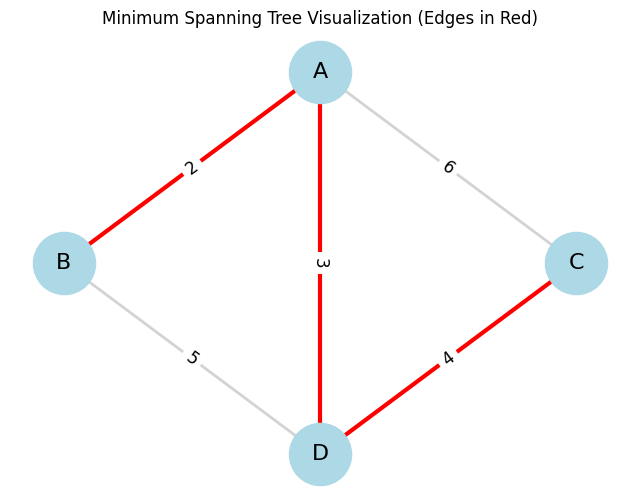

In [3]:
# 1. Graph mapping according to the provided image
graph_dict = {
    'A': {'B': 2, 'C': 6, 'D': 3},
    'B': {'A': 2, 'D': 5},
    'C': {'A': 6, 'D': 4},
    'D': {'A': 3, 'B': 5, 'C': 4}
}

# 2. Algorithm execution starting from vertex 'A'
mst_edges, total_cost = prim_algorithm(graph_dict, 'A')

# 3. Printing the results required by the assignment
print("--- PRIM'S ALGORITHM RESULT ---")
print("Component edges of the Minimum Spanning Tree (MST):")
for source, target, weight in mst_edges:
    print(f"Source Vertex: {source} -> Target Vertex: {target} | Weight: {weight}")

print(f"\nTotal cost (sum of weights): {total_cost}")
print("-" * 31)

# 4. Graphical Visualization
G = nx.Graph()

for source, connections in graph_dict.items():
    for target, weight in connections.items():
        G.add_edge(source, target, weight=weight)

# Define layout to match the provided image
pos = {
    'A': (0.5, 1),
    'B': (0, 0.5),
    'C': (1, 0.5),
    'D': (0.5, 0)
}

plt.figure(figsize=(8, 6))
plt.title("Minimum Spanning Tree Visualization (Edges in Red)")

# Draw all original nodes and edges (in light gray)
nx.draw(
    G, pos,
    with_labels=True,
    node_color='lightblue',
    node_size=2000,
    font_size=16,
    edge_color='lightgray',
    width=2
)

# Draw the MST edges on top (in red and thicker)
formatted_mst_edges = [
    (source, target) for source, target, weight in mst_edges
]

nx.draw_networkx_edges(
    G, pos,
    edgelist=formatted_mst_edges,
    edge_color='red',
    width=3
)

# Add weights to the edges
edge_weight_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_weight_labels,
    font_size=12
)

plt.show()